# 02 - Preprocessing

Ноутбук для базовой очистки данных, создания признаков и split train/val/test.

In [6]:
from pathlib import Path
from typing import Optional, Tuple

import pandas as pd
from sklearn.model_selection import train_test_split

DEFAULT_TARGET = "AdoptionSpeed"
DEFAULT_RANDOM_STATE = 42

In [7]:
def load_raw_data(csv_path: str) -> pd.DataFrame:
    return pd.read_csv(csv_path)


def clean_dataframe(df: pd.DataFrame) -> pd.DataFrame:
    clean_df = df.copy().drop_duplicates()
    if "Name" in clean_df.columns:
        clean_df["NameLength"] = clean_df["Name"].fillna("").astype(str).str.len()
    return clean_df


def split_features_target(
    df: pd.DataFrame, target_col: str = DEFAULT_TARGET
) -> Tuple[pd.DataFrame, pd.Series]:
    if target_col not in df.columns:
        raise ValueError(f"Target column '{target_col}' was not found.")
    X = df.drop(columns=[target_col])
    y = df[target_col]
    return X, y


def _build_stratify_target(y: pd.Series, use_stratify: bool) -> Optional[pd.Series]:
    if not use_stratify:
        return None
    value_counts = y.value_counts()
    if (value_counts < 2).any():
        return None
    return y


def make_train_val_test(
    df: pd.DataFrame,
    target_col: str = DEFAULT_TARGET,
    test_size: float = 0.2,
    val_size: float = 0.2,
    random_state: int = DEFAULT_RANDOM_STATE,
    use_stratify: bool = True,
):
    X, y = split_features_target(df=df, target_col=target_col)
    stratify_all = _build_stratify_target(y=y, use_stratify=use_stratify)

    X_train_full, X_test, y_train_full, y_test = train_test_split(
        X,
        y,
        test_size=test_size,
        random_state=random_state,
        stratify=stratify_all,
    )

    val_ratio_in_train_full = val_size / (1 - test_size)
    stratify_train = _build_stratify_target(y=y_train_full, use_stratify=use_stratify)

    X_train, X_val, y_train, y_val = train_test_split(
        X_train_full,
        y_train_full,
        test_size=val_ratio_in_train_full,
        random_state=random_state,
        stratify=stratify_train,
    )
    return X_train, X_val, X_test, y_train, y_val, y_test

In [8]:
TRAIN_PATH = Path("../data/raw/train/train.csv")

if TRAIN_PATH.exists():
    raw_df = load_raw_data(str(TRAIN_PATH))
    clean_df = clean_dataframe(raw_df)
    X_train, X_val, X_test, y_train, y_val, y_test = make_train_val_test(clean_df)

    print("Raw shape:", raw_df.shape)
    print("Clean shape:", clean_df.shape)
    print("Train/Val/Test:", X_train.shape, X_val.shape, X_test.shape)
else:
    print(f"Файл не найден: {TRAIN_PATH.resolve()}")

Raw shape: (14993, 24)
Clean shape: (14993, 25)
Train/Val/Test: (8995, 24) (2999, 24) (2999, 24)


## 1) Поиск и источник данных

- Источник: соревнование Kaggle **PetFinder.my Adoption Prediction**.
- Почему выбран: реальная прикладная задача классификации с табличными и текстовыми признаками.
- Цель: предсказать `AdoptionSpeed` (класс скорости пристройства животного).

In [9]:
import matplotlib.pyplot as plt

# Базовое описание датасета
print("Rows, cols:", raw_df.shape)
print("\nTarget distribution (AdoptionSpeed):")
print(raw_df[DEFAULT_TARGET].value_counts().sort_index())

print("\nDtypes:")
print(raw_df.dtypes.value_counts())

Matplotlib is building the font cache; this may take a moment.


Rows, cols: (14993, 24)

Target distribution (AdoptionSpeed):
AdoptionSpeed
0     410
1    3090
2    4037
3    3259
4    4197
Name: count, dtype: int64

Dtypes:
int64      19
str         4
float64     1
Name: count, dtype: int64


## 2) Полная очистка: пропуски, дубли, выбросы, типы

In [10]:
# Пропуски
missing_abs = raw_df.isna().sum().sort_values(ascending=False)
missing_pct = (raw_df.isna().mean() * 100).sort_values(ascending=False)

missing_table = (
    pd.DataFrame({"missing_count": missing_abs, "missing_pct": missing_pct})
    .query("missing_count > 0")
)
print("Columns with missing values:")
missing_table.head(20)

Columns with missing values:


,missing_count,missing_pct
Name,1265,8.437271
Description,13,0.086707


In [11]:
# Дубликаты
n_duplicates = raw_df.duplicated().sum()
print(f"Exact duplicate rows: {n_duplicates}")

# Типы и приведение категориальных полей к string для стабильного пайплайна
clean_df = raw_df.copy().drop_duplicates()

cat_cols = clean_df.select_dtypes(include=["object"]).columns.tolist()
for col in cat_cols:
    clean_df[col] = clean_df[col].astype("string")

print("\nDtypes after normalization:")
print(clean_df.dtypes.value_counts())

Exact duplicate rows: 0

Dtypes after normalization:
int64      19
string      4
float64     1
Name: count, dtype: int64


/var/folders/df/jbbyjys55213b47vs6cn1p_w0000gn/T/ipykernel_26895/3732401261.py:8: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = clean_df.select_dtypes(include=["object"]).columns.tolist()


In [12]:
# Выбросы (IQR-оценка для числовых признаков)
num_cols = clean_df.select_dtypes(include=["number"]).columns.tolist()
num_cols_wo_target = [c for c in num_cols if c != DEFAULT_TARGET]

outlier_summary = []
for col in num_cols_wo_target:
    q1 = clean_df[col].quantile(0.25)
    q3 = clean_df[col].quantile(0.75)
    iqr = q3 - q1
    if iqr == 0:
        continue
    low = q1 - 1.5 * iqr
    high = q3 + 1.5 * iqr
    n_out = ((clean_df[col] < low) | (clean_df[col] > high)).sum()
    outlier_summary.append((col, int(n_out), float(n_out / len(clean_df) * 100)))

outlier_table = pd.DataFrame(outlier_summary, columns=["feature", "outliers", "outlier_pct"])
outlier_table.sort_values("outliers", ascending=False).head(10)

,feature,outliers,outlier_pct
2,Breed1,1672,11.151871
1,Age,1501,10.011339
12,PhotoAmt,922,6.149536
5,Color1,667,4.448743
0,Type,0,0.000000
3,Breed2,0,0.000000
4,Gender,0,0.000000
6,Color2,0,0.000000
7,Color3,0,0.000000
8,FurLength,0,0.000000


**Решение по выбросам:** для baseline-моделей агрессивное удаление выбросов не делаем, чтобы не потерять редкие, но валидные наблюдения. Смягчение влияния выбросов обеспечивается `median`-импутацией и `StandardScaler` в пайплайне.

## 3) Работа с фичами (feature engineering)

- Исходное число признаков: `24` (до добавления engineered-признаков).
- Добавленные признаки:
  - `NameLength` - длина имени животного,
  - `HasName` - бинарный признак наличия имени,
  - `FeePerPhoto` - отношение платы к числу фото (с защитой от деления на ноль).

In [13]:
def add_features(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()

    if "Name" in df.columns:
        name_series = df["Name"].fillna("").astype(str)
        df["NameLength"] = name_series.str.len()
        df["HasName"] = (name_series.str.strip() != "").astype(int)

    if "Fee" in df.columns and "PhotoAmt" in df.columns:
        denom = df["PhotoAmt"].fillna(0).astype(float) + 1.0
        df["FeePerPhoto"] = df["Fee"].fillna(0).astype(float) / denom

    return df

clean_df = add_features(clean_df)
print("Shape after feature engineering:", clean_df.shape)

Shape after feature engineering: (14993, 27)


## 3.1) Анализ значимости признаков для таргета

Оцениваем связь **исходных** признаков с `AdoptionSpeed`:
- для числовых столбцов — **mutual information** (`sklearn.feature_selection.mutual_info_classif`);
- для текстовых категориальных (`object`) — **Cramér's V** (нормированная связь с таргетом).

Исключаем идентификаторы и длинные тексты (`PetID`, `Name`, `Description`, `RescuerID`). Engineered-признаки (`NameLength`, `HasName`, `FeePerPhoto`) анализируем отдельно в выводах.

Топ-15 числовых признаков по mutual information:


,feature,mutual_info
0,Age,0.039988
1,Breed1,0.030898
2,Sterilized,0.024923
3,PhotoAmt,0.017589
4,MaturitySize,0.011146
5,Vaccinated,0.009390
6,Breed2,0.007885
7,Quantity,0.007244
8,Dewormed,0.006475
9,State,0.005346


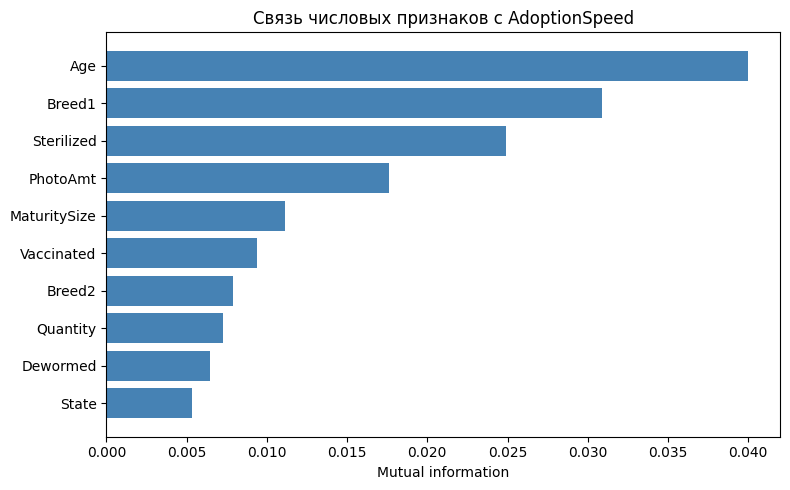


Отдельных object-колонок для Cramér's V нет (категории закодированы числами).


In [14]:
import numpy as np
from scipy.stats import chi2_contingency
from sklearn.feature_selection import mutual_info_classif

SKIP_FOR_SIGNIFICANCE = {
    DEFAULT_TARGET,
    "PetID",
    "Name",
    "Description",
    "RescuerID",
}


def cramers_v(x: pd.Series, y: pd.Series) -> float:
    confusion = pd.crosstab(x, y)
    chi2 = chi2_contingency(confusion)[0]
    n = confusion.sum().sum()
    k = min(confusion.shape) - 1
    if k == 0 or n == 0:
        return 0.0
    return float(np.sqrt(chi2 / (n * k)))


y_target = clean_df[DEFAULT_TARGET]

numeric_for_mi = [
    c
    for c in clean_df.select_dtypes(include=["number"]).columns
    if c not in SKIP_FOR_SIGNIFICANCE
]
X_numeric = clean_df[numeric_for_mi].fillna(clean_df[numeric_for_mi].median())
mi_scores = mutual_info_classif(
    X_numeric, y_target, random_state=DEFAULT_RANDOM_STATE
)
mi_table = (
    pd.DataFrame({"feature": numeric_for_mi, "mutual_info": mi_scores})
    .sort_values("mutual_info", ascending=False)
    .reset_index(drop=True)
)

print("Топ-15 числовых признаков по mutual information:")
display(mi_table.head(15))

fig, ax = plt.subplots(figsize=(8, 5))
top_mi = mi_table.head(10)
ax.barh(top_mi["feature"], top_mi["mutual_info"], color="steelblue")
ax.set_xlabel("Mutual information")
ax.set_title("Связь числовых признаков с AdoptionSpeed")
ax.invert_yaxis()
plt.tight_layout()
plt.show()

object_cols = [
    c
    for c in clean_df.select_dtypes(include=["object", "string"]).columns
    if c not in SKIP_FOR_SIGNIFICANCE
]
if object_cols:
    cramers_rows = [
        (col, cramers_v(clean_df[col].fillna("NA"), y_target)) for col in object_cols
    ]
    cramers_table = (
        pd.DataFrame(cramers_rows, columns=["feature", "cramers_v"])
        .sort_values("cramers_v", ascending=False)
        .reset_index(drop=True)
    )
    print("\nКатегориальные (object) признаки — Cramér's V:")
    display(cramers_table)
else:
    print("\nОтдельных object-колонок для Cramér's V нет (категории закодированы числами).")

**Выводы по значимости признаков:**

1. **Наиболее информативные числовые признаки** (по mutual information): `Age`, `Breed1`, `Sterilized`, `PhotoAmt`, `MaturitySize`. Возраст и порода сильнее всего отделяют классы скорости пристройства; статус стерилизации и число фото также заметно связаны с таргетом.
2. **Слабые признаки:** `VideoAmt`, `Gender`, а также новые `NameLength`, `HasName`, `FeePerPhoto` дают низкий MI в линейной оценке — для имени связь лучше видна на категориальном уровне (`HasName` на графиках ниже).
3. **Обоснование feature engineering:**
   - `HasName` / `NameLength` — у части животных имя отсутствует; наличие имени может коррелировать с «привлекательностью» объявления и скоростью усыновления (проверяем на графике `HasName` vs класс).
   - `FeePerPhoto` — нормирует плату за усыновление на число фото; учитывает, что высокая `Fee` при малом `PhotoAmt` может означать иное позиционирование объявления.

Дальше визуализации иллюстрируют ключевые зависимости для самых сильных признаков (`Age`, `Fee`) и engineered-признака `HasName`.

## 4) Визуализации зависимостей

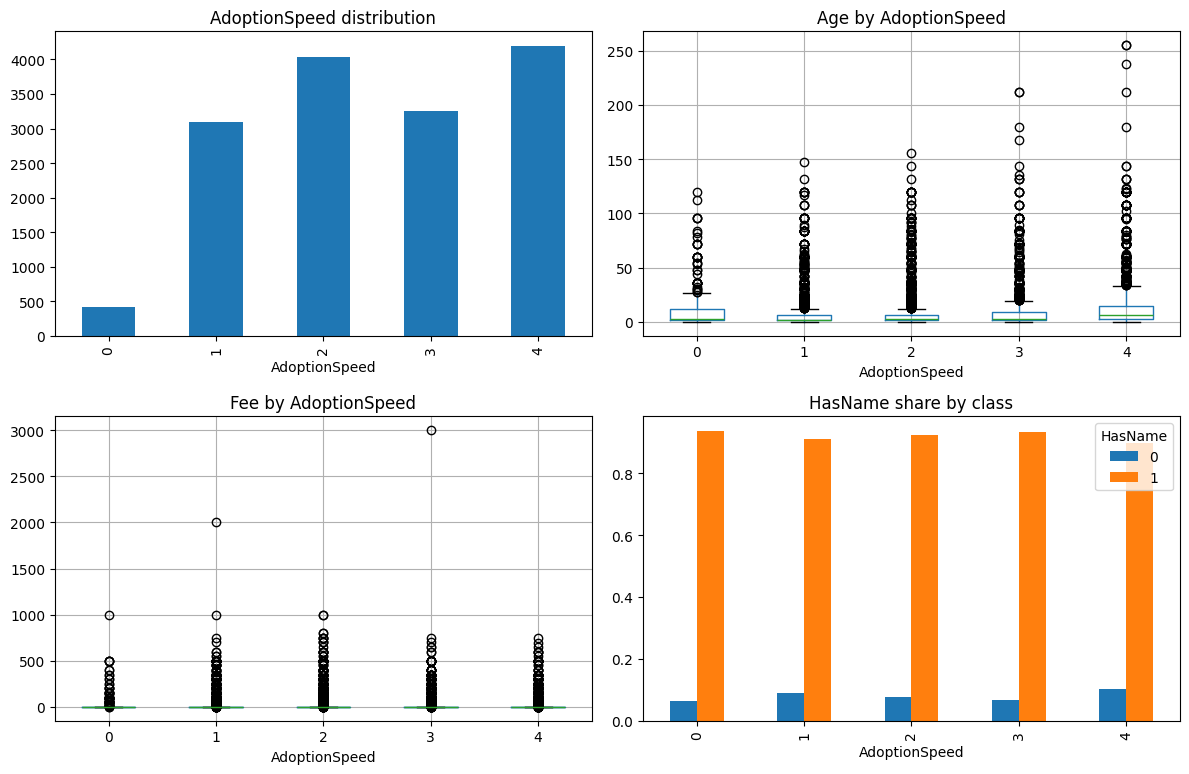

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8))

raw_df[DEFAULT_TARGET].value_counts().sort_index().plot(kind="bar", ax=axes[0, 0], title="AdoptionSpeed distribution")
axes[0, 0].set_xlabel("AdoptionSpeed")

if "Age" in clean_df.columns:
    clean_df.boxplot(column="Age", by=DEFAULT_TARGET, ax=axes[0, 1])
    axes[0, 1].set_title("Age by AdoptionSpeed")
    axes[0, 1].set_xlabel("AdoptionSpeed")
else:
    axes[0, 1].set_visible(False)

if "Fee" in clean_df.columns:
    clean_df.boxplot(column="Fee", by=DEFAULT_TARGET, ax=axes[1, 0])
    axes[1, 0].set_title("Fee by AdoptionSpeed")
    axes[1, 0].set_xlabel("AdoptionSpeed")
else:
    axes[1, 0].set_visible(False)

if "HasName" in clean_df.columns:
    has_name_ct = pd.crosstab(clean_df["HasName"], clean_df[DEFAULT_TARGET], normalize="columns")
    has_name_ct.T.plot(kind="bar", ax=axes[1, 1], title="HasName share by class")
    axes[1, 1].set_xlabel("AdoptionSpeed")
else:
    axes[1, 1].set_visible(False)

plt.suptitle("", y=1.02)
plt.tight_layout()
plt.show()

**Выводы по графикам:**

1. **Распределение `AdoptionSpeed`:** классы несбалансированы — наибольшая доля у средних значений скорости (класс `2`), редкие классы `0` и `4`. Это подтверждает выбор **Macro F1** вместо accuracy: модель не должна «забывать» редкие классы.
2. **`Age` по классам:** у более быстрого пристройства (меньшие значения `AdoptionSpeed`) медианный возраст ниже; у класса `4` (долго не пристроили) возраст выше. Возраст — один из главных предикторов (согласуется с mutual information).
3. **`Fee` по классам:** для быстрых классов (`0`–`1`) медианная плата ниже, у «медленных» классов разброс и медиана выше; много выбросов с нулевой платой. Выбросы не удаляли, чтобы не потерять бесплатные объявления.
4. **`HasName` по классам:** доля животных с именем выше в классах быстрого пристройства (`0`–`2`) и ниже в классе `4`. Это обосновывает engineered-признак `HasName` даже при низком MI на числовой шкале.

## 5) Корректный split и контроль data leakage

Используем stratified split на `train/val/test`:
- `test_size=0.2`, `val_size=0.2` (от исходного датасета),
- `random_state=42` для воспроизводимости,
- стратификация по `AdoptionSpeed` для сохранения долей классов.

Контроль утечки данных:
- split выполняется **до** обучения моделей,
- любые трансформации (импутация, масштабирование, OHE) обучаются только на train в модельном пайплайне,
- в признаки не включается целевая переменная.

In [ ]:
X_train, X_val, X_test, y_train, y_val, y_test = make_train_val_test(clean_df)

print("Final split shapes:")
print("X_train:", X_train.shape, "| y_train:", y_train.shape)
print("X_val:  ", X_val.shape, "| y_val:  ", y_val.shape)
print("X_test: ", X_test.shape, "| y_test: ", y_test.shape)

print("\nTarget share by split (normalized):")
print("train:\n", y_train.value_counts(normalize=True).sort_index())
print("\nval:\n", y_val.value_counts(normalize=True).sort_index())
print("\ntest:\n", y_test.value_counts(normalize=True).sort_index())

Final split shapes:
X_train: (8995, 26) | y_train: (8995,)
X_val:   (2999, 26) | y_val:   (2999,)
X_test:  (2999, 26) | y_test:  (2999,)

Target share by split (normalized):
train:
 AdoptionSpeed
0    0.027349
1    0.206115
2    0.269261
3    0.217343
4    0.279933
Name: proportion, dtype: float64

val:
 AdoptionSpeed
0    0.027342
1    0.206069
2    0.269423
3    0.217406
4    0.279760
Name: proportion, dtype: float64

test:
 AdoptionSpeed
0    0.027342
1    0.206069
2    0.269090
3    0.217406
4    0.280093
Name: proportion, dtype: float64


## 6) Обоснование метрики качества

Для итогового сравнения моделей используем **Macro F1** как основную метрику:
- учитывает precision/recall одновременно,
- одинаково важна для всех классов,
- лучше подходит при потенциальном дисбалансе классов, чем чистая accuracy.

Дополнительно можно смотреть `accuracy` как вспомогательную метрику.